### Car vs Truck Image Classification using CNN (Modified Version)

In this project, we build a Convolutional Neural Network (CNN) to classify images as either Car or Truck.

We modified the original tutorial by:

- Changing optimizer to RMSprop
- Adding extra Conv2D layer
- Increasing Dense layer size
- Adding Dropout layer
- Changing batch size
- Increasing epochs

This helps improve performance and understand CNN architecture better.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

### Load the Dataset

We load the images from train and validation folders.

Batch size defines how many images the model sees at once.

In [21]:
batch_size = 16
image_size = (180, 180)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    image_size=image_size,
    batch_size=batch_size
)

Found 5117 files belonging to 2 classes.
Found 5051 files belonging to 2 classes.


### Normalize the Images

Rescaling converts pixel values from 0–255 to 0–1.

This helps the model learn better.

In [22]:
 normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

### Build the CNN Model

We added:

- Extra Conv2D layer
- Larger Dense layer
- Dropout layer to prevent overfitting

In [23]:
model = keras.Sequential([

    layers.Conv2D(32, 3, activation="relu", input_shape=(180,180,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")

])

### Compile the Model

We use RMSprop optimizer instead of Adam.

Loss function: binary_crossentropy  
Metric: accuracy

In [24]:
model.compile(

    optimizer=keras.optimizers.RMSprop(learning_rate=0.0001),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

### View Model Summary

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    13,107,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,200,961 (50.36 MB)

 Trainable params: 13,200,961 (50.36 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

We train for 15 epochs.

Epoch means one full learning cycle through dataset.

In [26]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5

)

Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 170s 528ms/step - accuracy: 0.6134 - loss: 0.6584 - val_accuracy: 0.6733 - val_loss: 0.6234
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 162s 505ms/step - accuracy: 0.6772 - loss: 0.5990 - val_accuracy: 0.6719 - val_loss: 0.6048
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 161s 504ms/step - accuracy: 0.7332 - loss: 0.5485 - val_accuracy: 0.7189 - val_loss: 0.5567
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 158s 495ms/step - accuracy: 0.7581 - loss: 0.5004 - val_accuracy: 0.7203 - val_loss: 0.5431
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 200s 488ms/step - accuracy: 0.7862 - loss: 0.4623 - val_accuracy: 0.6809 - val_loss: 0.6533


### Result

Model learns to classify images as Car or Truck.

Accuracy improves over time.

This CNN can now predict vehicle type from image.

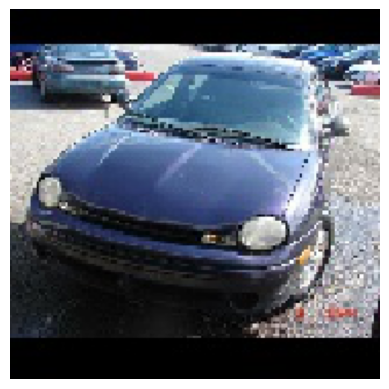

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Prediction: Car 🚗
Confidence: 0.027580999


In [27]:


# Path to your test image
img_path = "test_image.jpeg"   # change this to your image path


# Load image
img = load_img(img_path, target_size=(180, 180))

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()


# Convert to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize
img_array = img_array / 255.0


# Predict
prediction = model.predict(img_array)


# Print result
if prediction[0][0] > 0.5:
    print("Prediction: Truck 🚚")
else:
    print("Prediction: Car 🚗")


# Print confidence
print("Confidence:", prediction[0][0])